In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Part (a): Free Spacecraft Motion ($u = 0$)

**Objective:**
Simulate the uncontrolled motion of the spacecraft for $t \in [0, 60]$ seconds in the absence of any control input ($u = 0$). We assume a non-zero initial angular velocity to observe the natural dynamics. Additionally, we have the plots of the angular velocities and it can be seen that the states remain bounded. Also, in the last plot it can be seen that the unit norm constrained is maintained on the state quaternion. 

**System Dynamics:**
The motion of the rigid spacecraft is governed by the following equations:
1. **Kinematics (Quaternion Derivative):**
   $$\dot{q} = \frac{1}{2}E(q)\omega$$
2. **Dynamics (Euler's Equation):**
   $$J\dot{\omega} = -\omega \times J\omega + u$$
   Since the system is in free motion ($u = 0$), this simplifies to $J\dot{\omega} = -\omega \times J\omega$.

**Given Parameters & Initial Conditions:**
* **Inertia Matrix ($J$):** 
  $$J = \begin{bmatrix} 20.0 & 1.2 & 0.9 \\ 1.2 & 17.0 & 1.4 \\ 0.9 & 1.4 & 15.0 \end{bmatrix}$$
* **Initial Attitude ($q(0)$):** 
  Given the vector part $q_v(0) = [0.1826, 0.1826, 0.1826]^T$, the scalar part is calculated using the negative root: 
  $$q_o(0) = -\sqrt{1 - \|q_v(0)\|^2}$$
* **Initial Angular Velocity ($\omega(0)$):**
  We initialize the system with an arbitrary non-zero velocity: $\omega(0) = [0.5, -0.2, -0.3]^T$ rad/s.

Initial quaternion  : [-0.94866839  0.1826      0.1826      0.1826    ]
Initial ||q||       : 1.000000
Initial ω (rad/s)   : [ 0.5 -0.2 -0.3]


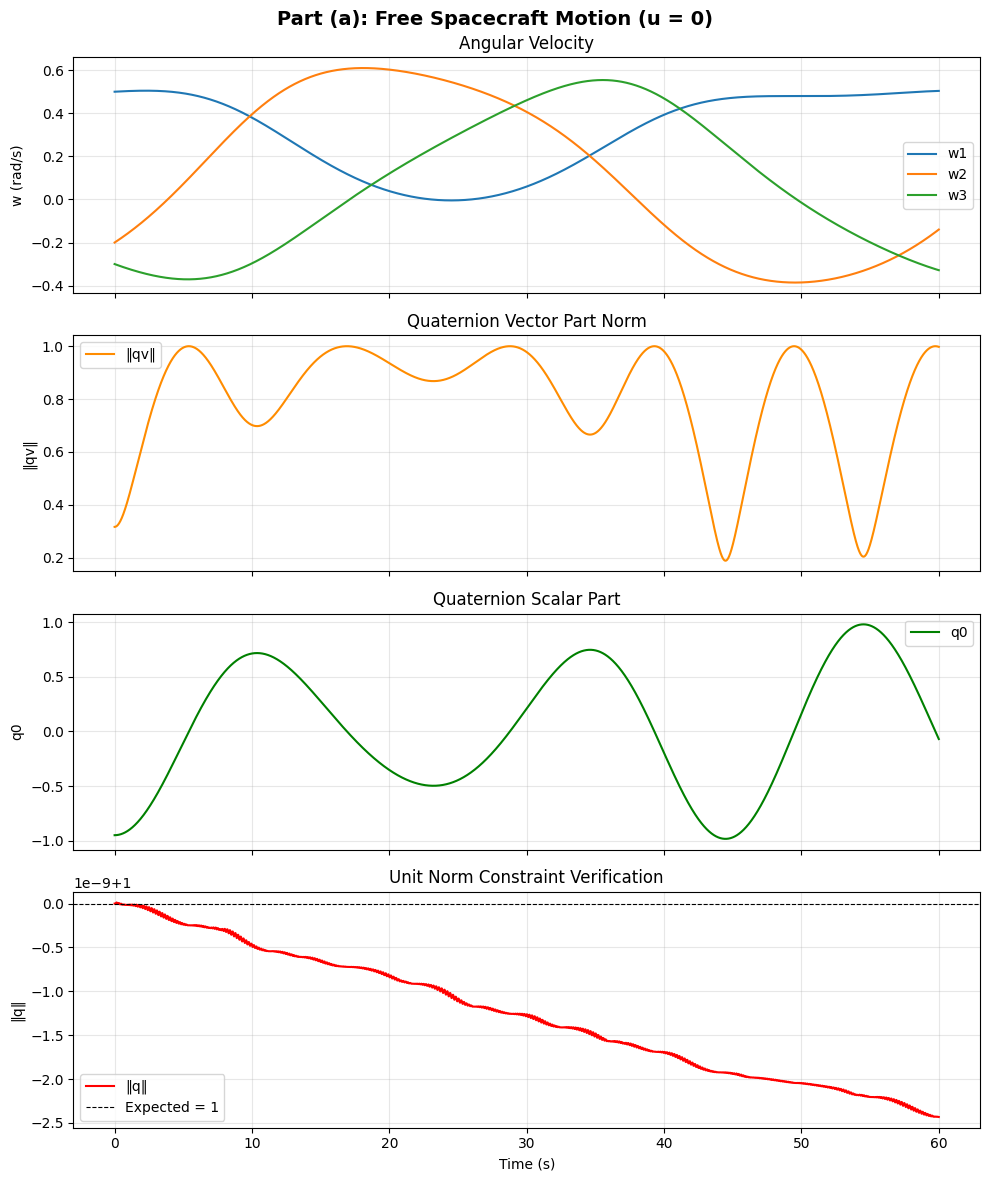

In [17]:
def skew(v):
    """Skew-symmetric matrix S(v) such that S(v)u = v cross u"""
    return np.array([
        [ 0,    -v[2],  v[1]],
        [ v[2],  0,    -v[0]],
        [-v[1],  v[0],  0   ]
    ])
 
def E_matrix(q):
    """E(q) matrix for quaternion kinematics: dq/dt = 0.5 * E(q) * w"""
    q0 = q[0]
    qv = q[1:]
    top = -qv.reshape(1, 3)                        # 1×3
    bot = q0 * np.eye(3) + skew(qv)               # 3×3
    return np.vstack([top, bot])                   # 4×3
 

J = np.array([
    [20.0, 1.2, 0.9],
    [ 1.2, 17.0, 1.4],
    [ 0.9,  1.4, 15.0]
])
J_inv = np.linalg.inv(J)


qv0 = np.array([0.1826, 0.1826, 0.1826])
q0_scalar = -np.sqrt(1.0 - np.dot(qv0, qv0))  # negative root as given
q_init = np.array([q0_scalar, *qv0])       
 
# Initial angular velocity (rad/s) — free choice
omega_init = np.array([0.5, -0.2, -0.3])
 
# Full state vector: [q0, qv1, qv2, qv3, w1, w2, w3]
x0 = np.concatenate([q_init, omega_init])
 
print(f"Initial quaternion  : {q_init}")
print(f"Initial ||q||       : {np.linalg.norm(q_init):.6f}")
print(f"Initial ω (rad/s)   : {omega_init}")
 

def spacecraft_ode(t, x):
    q     = x[0:4]   
    omega = x[4:7]   
 
    # --- Quaternion kinematics: dq/dt = 0.5 * E(q) * w ---
    dq = 0.5 * E_matrix(q) @ omega
 
    # --- Euler's equation: J*dω/dt = -w × Jw  (u = 0) ---
    Jomega   = J @ omega
    domega   = J_inv @ (-np.cross(omega, Jomega))
 
    return np.concatenate([dq, domega])
 
 
t_span = (0, 60)
t_eval = np.linspace(0, 60, 6000)
 
sol = solve_ivp(
    spacecraft_ode,
    t_span,
    x0,
    method='RK45',
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-11
)
 
t   = sol.t
q0  = sol.y[0]       
qv  = sol.y[1:4]     
om  = sol.y[4:7]     
 

qv_norm = np.linalg.norm(qv, axis=0)          # ||qv||
q_norm  = np.sqrt(q0**2 + qv_norm**2)         # ||q|| — should stay = 1
 
 
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
fig.suptitle('Part (a): Free Spacecraft Motion (u = 0)', fontsize=14, fontweight='bold')
 
# --- Angular velocity ---
ax = axes[0]
for i, label in enumerate(['w1', 'w2', 'w3']):
    ax.plot(t, om[i], label=label)
ax.set_ylabel('w (rad/s)')
ax.set_title('Angular Velocity')
ax.legend()
ax.grid(True, alpha=0.3)
 
# --- Quaternion vector norm ---
ax = axes[1]
ax.plot(t, qv_norm, color='darkorange', label='‖qv‖')
ax.set_ylabel('‖qv‖')
ax.set_title('Quaternion Vector Part Norm')
ax.legend()
ax.grid(True, alpha=0.3)
 
# --- Scalar part q0 ---
ax = axes[2]
ax.plot(t, q0, color='green', label='q0')
ax.set_ylabel('q0')
ax.set_title('Quaternion Scalar Part')
ax.legend()
ax.grid(True, alpha=0.3)
 
# --- Unit norm verification ---
ax = axes[3]
ax.plot(t, q_norm, color='red', label='‖q‖')
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, label='Expected = 1')
ax.set_ylabel('‖q‖')
ax.set_xlabel('Time (s)')
ax.set_title('Unit Norm Constraint Verification')
ax.legend()
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()


## Part (b): Spacecraft Stabilization Control

**Objective:**
Design and simulate a feedback control law $u(t)$ to stabilize the spacecraft, driving the angular velocity ($\omega$) and the vector part of the quaternion ($q_v$) to zero. The controller gains must be tuned such that the state norm $\|[\omega, q_v]^T\| < 10^{-3}$ for all $t \ge 20$ seconds.

**Control Law:**
The general control law provided at the beginning of the assignment is designed for trajectory tracking. However, because the objective here is pure stabilization (bringing the spacecraft to a complete rest at the target orientation), the desired angular velocity is zero ($\omega_d = 0$). Since ($\omega_d = 0$), the error quaternion s is just the current state quaternion q. Substituting $\omega_d = 0$ into the general tracking equation reduces it directly to the following stabilization control law:
$$u = k_p q_v - k_w \omega + \omega \times (J\omega)$$

$+$ has been used with $q_v$ instead of - since we start near -1, and it is easier to drive the scalar part to -1 rather than +1, and nevertheless both represent the same final state.

**Gain Selection:**
To meet the strict settling time requirement of $\|[\omega, q_v]^T\| < 10^{-3}$ for $t \ge 20$ s, the proportional and derivative gains were tuned to the following values:
* Proportional Gain ($k_p$) = 20.0
* Derivative Gain ($k_w$) = 30.0

‖[w, qv]‖ < 1e-3 for all t ≥ 20s ? YES
Max ‖[w, qv]‖ at t≥20s : 9.91e-05
Max |‖q‖ - 1|           : 4.32e-11


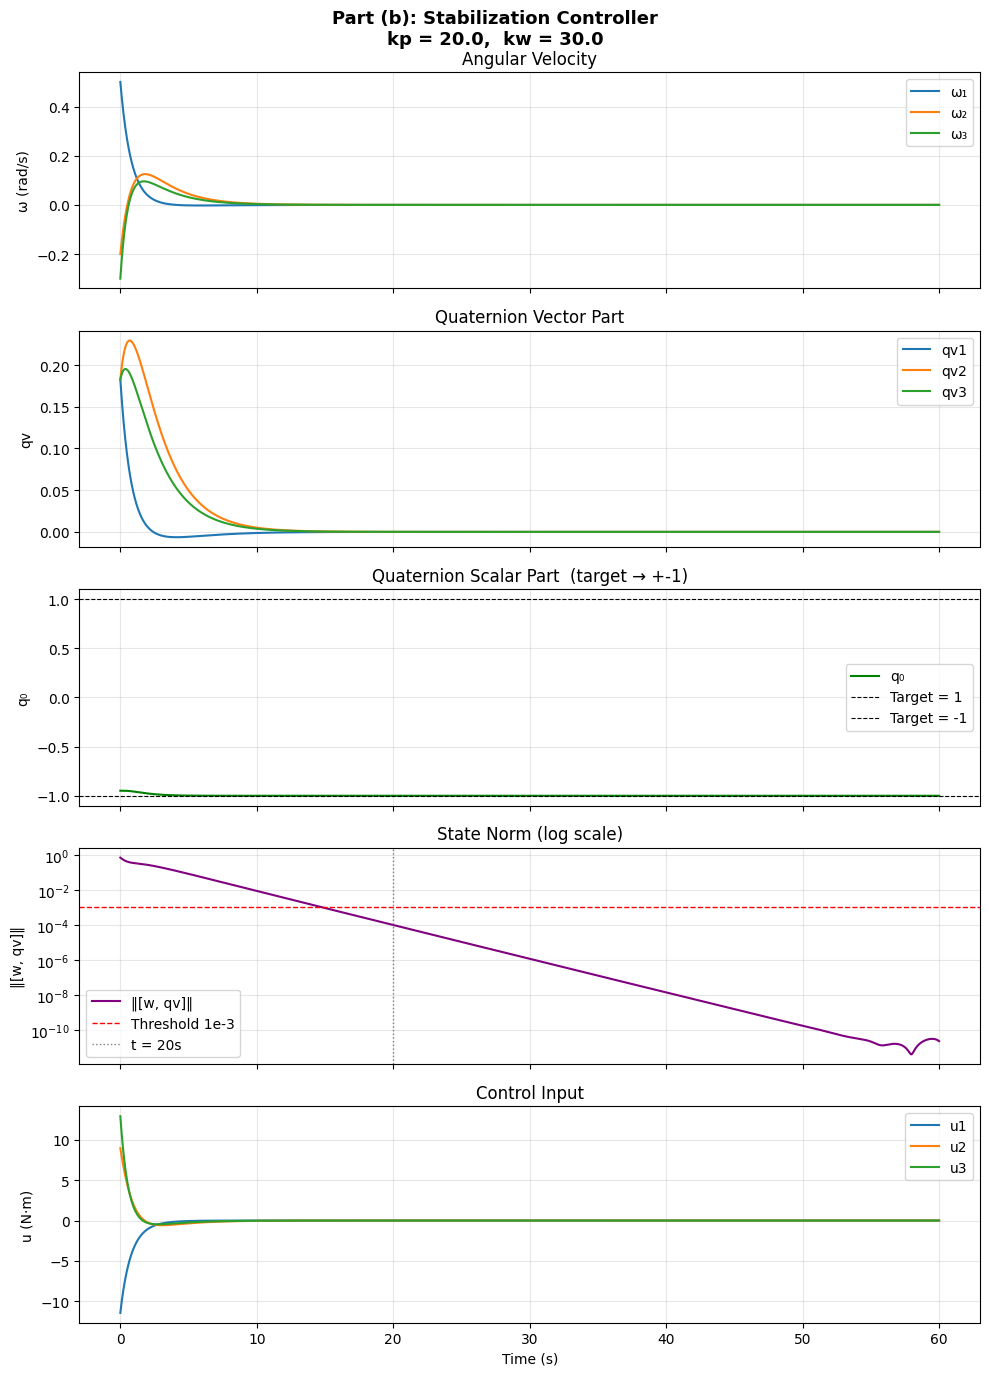

In [18]:
kp = 20.0  
kw = 30.0

def control(q, omega):
    """
    u = +kp*qv - kw*w + w cross Jw
 
    The + instead of the - mentioned at the beginning of the homework pdf, because 
    we can have q0 go to either +1 or -1 (both represent the same target orientation).
    Since it starts near -1, we use +kp*qv to drive it towards -1, which would take less effort and time.
    The corresponding Lyapunov term is 2*kp*(1 + q0). 
    """
    qv    = q[1:]
    Jom   = J @ omega
    u     = kp * qv - kw * omega + np.cross(omega, Jom)
    return u

 
def spacecraft_controlled(t, x):
    q     = x[0:4]
    omega = x[4:7]
 
    u      = control(q, omega)
    dq     = 0.5 * E_matrix(q) @ omega
    domega = J_inv @ (-np.cross(omega, J @ omega) + u)
 
    return np.concatenate([dq, domega])
 

t_span = (0, 60)
t_eval = np.linspace(0, 60, 6000)
 
sol = solve_ivp(spacecraft_controlled, t_span, x0,
                method='RK45', t_eval=t_eval,
                rtol=1e-9, atol=1e-11)
 
t      = sol.t
q0_arr = sol.y[0]
qv     = sol.y[1:4]
om     = sol.y[4:7]
 
# Control signal (recompute at each time step)
u_hist = np.array([control(sol.y[0:4, i], sol.y[4:7, i])
                   for i in range(len(t))]).T 
 
qv_norm   = np.linalg.norm(qv, axis=0)
q_norm    = np.sqrt(q0_arr**2 + qv_norm**2)
state_norm = np.sqrt(np.sum(om**2, axis=0) + qv_norm**2)   # ‖[ω, qv]‖
 
# Check requirement
idx_20 = np.searchsorted(t, 20.0)
req_met = np.all(state_norm[idx_20:] < 1e-3)
print(f"‖[w, qv]‖ < 1e-3 for all t ≥ 20s ? {'YES' if req_met else 'NO'}")
print(f"Max ‖[w, qv]‖ at t≥20s : {state_norm[idx_20:].max():.2e}")
print(f"Max |‖q‖ - 1|           : {np.max(np.abs(q_norm - 1)):.2e}")
 

fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)
fig.suptitle('Part (b): Stabilization Controller\n'
             f'kp = {kp},  kw = {kw}', fontsize=13, fontweight='bold')
 
# Angular velocity
ax = axes[0]
for i, lbl in enumerate(['ω₁', 'ω₂', 'ω₃']):
    ax.plot(t, om[i], label=lbl)
ax.set_ylabel('ω (rad/s)')
ax.set_title('Angular Velocity')
ax.legend(); ax.grid(True, alpha=0.3)
 
# qv components
ax = axes[1]
for i, lbl in enumerate(['qv1', 'qv2', 'qv3']):
    ax.plot(t, qv[i], label=lbl)
ax.set_ylabel('qv')
ax.set_title('Quaternion Vector Part')
ax.legend(); ax.grid(True, alpha=0.3)
 
# q0
ax = axes[2]
ax.plot(t, q0_arr, color='green', label='q₀')
ax.axhline(1.0, color='black', linestyle='--', lw=0.8, label='Target = 1')
ax.axhline(-1.0, color='black', linestyle='--', lw=0.8, label='Target = -1')
ax.set_ylabel('q₀')
ax.set_title('Quaternion Scalar Part  (target → +-1)')
ax.legend(); ax.grid(True, alpha=0.3)
 
# State norm with threshold line
ax = axes[3]
ax.semilogy(t, state_norm, color='purple', label='‖[w, qv]‖')
ax.axhline(1e-3, color='red', linestyle='--', lw=1, label='Threshold 1e-3')
ax.axvline(20.0, color='gray', linestyle=':', lw=1, label='t = 20s')
ax.set_ylabel('‖[w, qv]‖')
ax.set_title('State Norm (log scale)')
ax.legend(); ax.grid(True, alpha=0.3)
 
# Control signals
ax = axes[4]
for i, lbl in enumerate(['u1', 'u2', 'u3']):
    ax.plot(t, u_hist[i], label=lbl)
ax.set_ylabel('u (N·m)')
ax.set_xlabel('Time (s)')
ax.set_title('Control Input')
ax.legend(); ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

## Part (c): Trajectory Tracking (Known Inertia)

**Objective:**
Simulate the spacecraft to track a time-varying desired angular velocity trajectory $\omega_d(t)$ and its analytical derivative $\dot{\omega}_d(t)$, assuming the true inertia matrix $J$ is fully known.

**Error Variables:**
The tracking errors and feedforward terms are defined as follows:
* **Attitude Error Quaternion:** $s = q_d^* \otimes q$ (where $s_v$ is the vector part of $s$)
* **Velocity Error:** $\delta\omega = \omega - R(s)\omega_d$
* **Feedforward Term:** $\phi = -S(\delta\omega)R(s)\omega_d + R(s)\dot{\omega}_d$

**Control Law:**
The exact tracking control law provided in the assignment is used to drive the tracking errors $s_v$ and $\delta\omega$ to zero:
$$u = k_p s_v - k_w \delta\omega + \omega \times (J\omega) + J\phi$$

**Simulation Parameters:**
* **Proportional Gain ($k_p$):** 2.0
* **Derivative Gain ($k_w$):** 7.5
* **Initial Conditions:** The spacecraft starts from rest ($\omega(0) = [0, 0, 0]^T$ rad/s) with the target orientation initialized at $q_d(0) = [1, 0, 0, 0]^T$. The initial spacecraft attitude $q(0)$ remains the same as in previous parts.

- The controls aren't strictly less that 5 N.m, but that is the closest to the required bound that I could get. Turns out that even after tracking error goes to zero, you require controls a bit more that 5 at two of the axis to manauever in the desired orientaton.

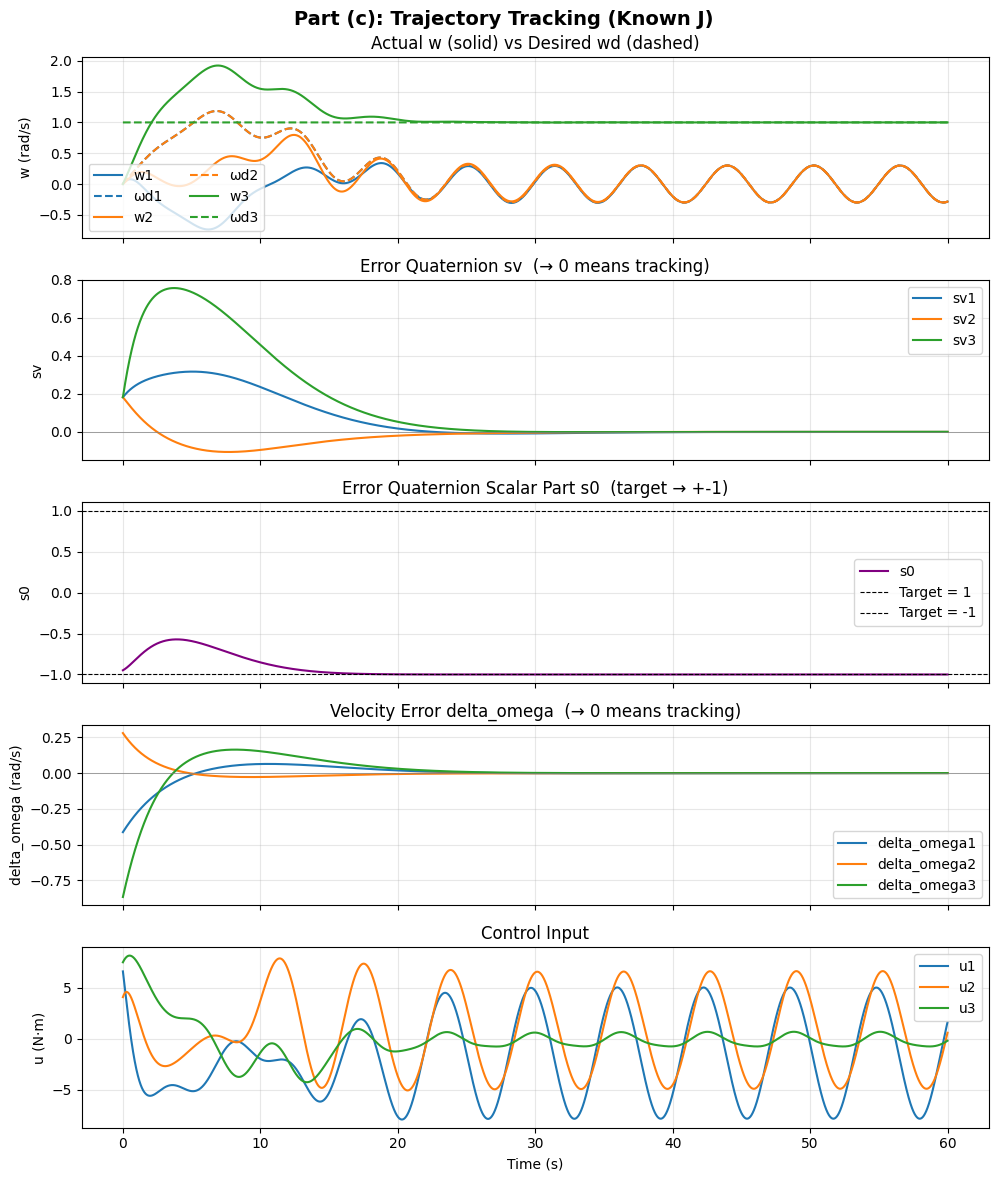

In [19]:
kp = 2
kw = 7

def omega_d(t):
    e = np.exp(-0.01 * t**2)
    f = 0.3*np.cos(t)*(1 - e) + (0.08*np.pi + 0.006*np.sin(t))*t*e
    return np.array([f, f, 1.0])

def omega_d_dot(t):
    e  = np.exp(-0.01 * t**2)
    de = -0.02 * t * e
 
    dA = -0.3*np.sin(t)*(1 - e) + 0.3*np.cos(t)*(-de)
 
    h  = 0.08*np.pi + 0.006*np.sin(t)
    dh = 0.006*np.cos(t)
    dB = dh*t*e + h*e + h*t*de
 
    df = dA + dB
    return np.array([df, df, 0.0])

def quat_to_rot(q):
    """Quaternion to correspondinf rotation matrix R(q)"""
    q0 = q[0]
    qv = q[1:]

    return (q0**2 - np.dot(qv, qv)) * np.eye(3) \
           + 2.0 * np.outer(qv, qv) \
           - 2.0 * q0 * skew(qv)

def hamilton_product(p, q):
    """Quaternion Product"""

    scalar = p[0]*q[0] - np.dot(p[1:], q[1:])
    vector = p[0]*q[1:] + q[0]*p[1:] + np.cross(p[1:], q[1:])

    return np.array([scalar, *vector])

def quat_conj(q):
    """Conjugate of a quaternion = q*"""

    return np.array([q[0], -q[1], -q[2], -q[3]])


def compute_control(t, q, omega, qd):

    wd  = omega_d(t)
    wdd = omega_d_dot(t)
 
    # Error quaternion s = hamilton product of qd* and q
    s   = hamilton_product(quat_conj(qd), q)
    s = s / np.linalg.norm(s)
    Rs  = quat_to_rot(s)
 
    Rswd        = Rs @ wd                                # wd in body frame
    delta_omega = omega - Rswd                           # velocity error
 
    phi = (-skew(delta_omega) @ Rs) @ wd + (Rs @ wdd)       # feedforward phi
 
    u = (+kp *  s[1:]
         - kw * delta_omega
         + np.cross(omega, J @ omega)
         + J @ phi)
 
    return u, s, delta_omega

qv_0    = np.array([0.1826, 0.1826, 0.1826])
q0_0   = -np.sqrt(1.0 - np.dot(qv0, qv0))
q_init = np.array([q0_0, *qv_0])
om_init = np.array([0, 0, 0])
qd_init = np.array([1.0, 0.0, 0.0, 0.0])

x0 = np.concatenate([q_init, om_init, qd_init])

def controlled_ode(t, x):
    q     = x[0:4]
    omega = x[4:7]
    qd    = x[7:11]
 
    u, _, _ = compute_control(t, q, omega, qd)
 
    dq  = 0.5 * (E_matrix(q)  @ omega)
    dom = J_inv @ (-np.cross(omega, J @ omega) + u)
    dqd = 0.5 * (E_matrix(qd) @ omega_d(t))
 
    return np.concatenate([dq, dom, dqd])

t_span = (0, 60)
t_eval = np.linspace(0, 60, 6000)
 
sol = solve_ivp(controlled_ode, t_span, x0,
                method='RK45', t_eval=t_eval,
                rtol=1e-9, atol=1e-11)
 
t      = sol.t
q_sol  = sol.y[0:4]
om_sol = sol.y[4:7]
qd_sol = sol.y[7:11]

fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=True)
fig.suptitle('Part (c): Trajectory Tracking (Known J)', fontsize=14, fontweight='bold')

# --- w actual vs desired ---
ax = axes[0]
colors = ['tab:blue', 'tab:orange', 'tab:green']
omega_d_t = np.array([omega_d(ti) for ti in t])   # shape (N, 3)
for i in range(3):
    ax.plot(t, om_sol[i],          color=colors[i], label=f'w{i+1}')
    ax.plot(t, omega_d_t[:, i], '--', color=colors[i], lw=1.5, label=f'ωd{i+1}')
ax.set_ylabel('w (rad/s)')
ax.set_title('Actual w (solid) vs Desired wd (dashed)')
ax.legend(ncol=2)
ax.grid(True, alpha=0.3)

# --- Error quaternion sv ---
for i in range(len(t)):
    q  = q_sol[:, i]  / np.linalg.norm(q_sol[:, i])
    qd = qd_sol[:, i] / np.linalg.norm(qd_sol[:, i])
    # already have sv from recomputing below

sv_hist = np.zeros((3, len(t)))
s0_hist = np.zeros(len(t))
dw_hist = np.zeros((3, len(t)))
u_hist  = np.zeros((3, len(t)))
for i in range(len(t)):
    q  = q_sol[:, i]  / np.linalg.norm(q_sol[:, i])
    qd = qd_sol[:, i] / np.linalg.norm(qd_sol[:, i])
    u, s, dw      = compute_control(t[i], q, om_sol[:, i], qd)
    sv_hist[:, i] = s[1:]
    s0_hist[i]    = s[0]
    dw_hist[:, i] = dw
    u_hist[:, i]  = u

ax = axes[1]
for i, lbl in enumerate(['sv1', 'sv2', 'sv3']):
    ax.plot(t, sv_hist[i], label=lbl)
ax.axhline(0, color='gray', lw=0.5)
ax.set_ylabel('sv')
ax.set_title('Error Quaternion sv  (→ 0 means tracking)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(t, s0_hist, color='purple', label='s0')
ax.axhline(1.0, color='black', linestyle='--', lw=0.8, label='Target = 1')
ax.axhline(-1.0, color='black', linestyle='--', lw=0.8, label='Target = -1')
ax.set_ylabel('s0')
ax.set_title('Error Quaternion Scalar Part s0  (target → +-1)')
ax.legend(); ax.grid(True, alpha=0.3)

# --- δω ---
ax = axes[3]
for i, lbl in enumerate(['delta_omega1', 'delta_omega2', 'delta_omega3']):
    ax.plot(t, dw_hist[i], label=lbl)
ax.axhline(0, color='gray', lw=0.5)
ax.set_ylabel('delta_omega (rad/s)')
ax.set_title('Velocity Error delta_omega  (→ 0 means tracking)')
ax.legend(); ax.grid(True, alpha=0.3)

# --- Control ---
ax = axes[4]
for i, lbl in enumerate(['u1', 'u2', 'u3']):
    ax.plot(t, u_hist[i], label=lbl)
ax.set_ylabel('u (N·m)')
ax.set_xlabel('Time (s)')
ax.set_title('Control Input')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part (d): Integrator Backstepping Control

* Derivation and analysis in the handwritten pdf. 

## Part (e): Adaptive Backstepping Tracking (Unknown Inertia)

**Objective:**
Simulate spacecraft trajectory tracking assuming the true inertia matrix $J$ is unknown, using an adaptive integrator backstepping approach. 

* Derivation nd analysis of the control law is in the handwritten notes.

**Backstepping Error Formulation:**
Instead of a single error surface, backstepping defines a composite tracking error $z$ based on a virtual kinematic control target:
$$z = \delta\omega - c_1 s_v$$

To isolate the unknown parameters from the plant dynamics, we define the standard regressor $W(\omega, \phi) = -S(\omega)L(\omega) - L(\phi)$ and augment it into a new backstepping regressor $W_1$ that accounts for the kinematic derivative $\dot{s}_v$:
$$W_1 = -W + c_1 L(\dot{s}_v)$$

**Control Law:**
Using the backstepping regressor $W_1$ and the current parameter estimates $\hat{\theta}$, the final actual control torque applied to the spacecraft is:
$$u = s_v - c_2 z + W_1 \hat{\theta}$$

**Parameter Update Law:**
The inertia parameter estimates are continuously adapted using the following update law driven by the backstepping error $z$:
$$\dot{\hat{\theta}} = -\Gamma W_1^T z$$

**Simulation Parameters:**
* **Kinematic Gain ($c_1$):** 1.0
* **Dynamic Gain ($c_2$):** 5.0
* **Adaptation Rate ($\Gamma$):** $5.0 I_{6\times6}$
* **Initial Conditions:** The spacecraft starts from rest ($\omega(0) = [0, 0, 0]^T$ rad/s). To verify the adaptation, the parameter estimates are intentionally initialized at a 30% offset from the true inertia values ($\hat{\theta}_{init} = 0.7\theta_{true}$).

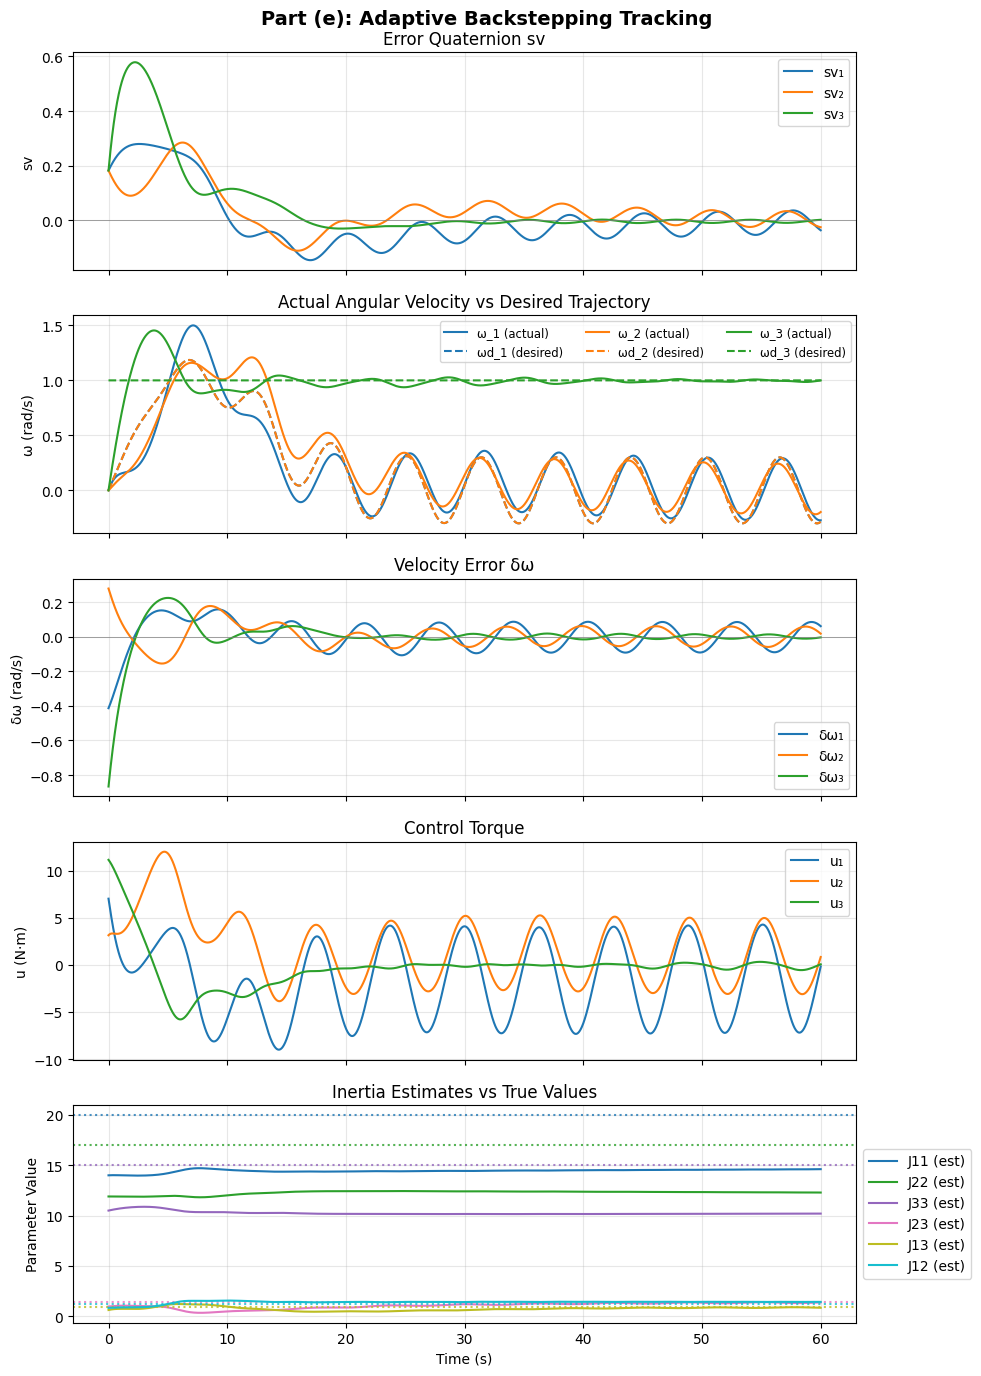

In [20]:
c1 = 1
c2 = 5.0
Gamma = 0.5 * np.eye(6)  # Adaptation rate


def J_to_theta(J):
    return np.array([J[0,0], J[1,1], J[2,2], J[1,2], J[0,2], J[0,1]])

theta_true = J_to_theta(J)

# 30% offset for initial parameter estimates
theta_hat_init = 0.7 * theta_true

def L_matrix(v):
    """Helper matrix to factor out theta from J*v"""
    return np.array([
        [v[0],  0,  0,  0, v[2], v[1]],
        [ 0, v[1],  0, v[2],  0, v[0]],
        [ 0,  0, v[2], v[1], v[0],  0]
    ])

def compute_adaptive_backstepping_control(t, q, omega, qd, theta_hat):
    wd  = omega_d(t)
    wdd = omega_d_dot(t)
 
    # Error quaternion: s = qd* ⊗ q
    s = hamilton_product(quat_conj(qd), q)
    s = s / np.linalg.norm(s)
    s0, sv = s[0], s[1:]
    Rs = quat_to_rot(s)
 
    Rswd = Rs @ wd
    delta_omega = omega - Rswd
    phi = -np.cross(delta_omega, Rswd) + Rs @ wdd
    
    # 1. Backstepping Error
    z = delta_omega - c1 * sv 
    
    # 2. Kinematic derivative
    sv_dot = 0.5 * (s0 * np.eye(3) + skew(sv)) @ delta_omega
    
    # 3. Backstepping Regressor Matrix Y
    W = -skew(omega) @ L_matrix(omega) - L_matrix(phi)
    W1 = -W + (c1) * L_matrix(sv_dot)
    
    # 4. Control Law (u)
    u = sv - c2 * z + W1 @ theta_hat
    
    # 5. Parameter Update Law
    d_theta_hat = - Gamma @ W1.T @ z
 
    return u, d_theta_hat, s, delta_omega


def adaptive_controlled_ode(t, x):
    q         = x[0:4] / np.linalg.norm(x[0:4])
    omega     = x[4:7]
    qd        = x[7:11] / np.linalg.norm(x[7:11])
    theta_hat = x[11:17]
 
    u, d_theta_hat, _, _ = compute_adaptive_backstepping_control(t, q, omega, qd, theta_hat)
 
    dq  = 0.5 * (E_matrix(q)  @ omega)
    dqd = 0.5 * (E_matrix(qd) @ omega_d(t))
    dom = J_inv @ (-np.cross(omega, J @ omega) + u)
 
    return np.concatenate([dq, dom, dqd, d_theta_hat])

qv0     = np.array([0.1826, 0.1826, 0.1826])
q0_s    = -np.sqrt(1.0 - np.dot(qv0, qv0)) 
q_init  = np.array([q0_s, *qv0])
om_init = np.array([0, 0, 0])
qd_init = np.array([1.0, 0.0, 0.0, 0.0])

x0 = np.concatenate([q_init, om_init, qd_init, theta_hat_init])
t_eval = np.linspace(0, 60, 3000)

sol = solve_ivp(adaptive_controlled_ode, (0, 60), x0, method='RK45', t_eval=t_eval, rtol=1e-8, atol=1e-10)

t, q_sol, om_sol, qd_sol, theta_hat_sol = sol.t, sol.y[0:4], sol.y[4:7], sol.y[7:11], sol.y[11:17]

sv_hist = np.zeros((3, len(t)))
dw_hist = np.zeros((3, len(t)))
u_hist  = np.zeros((3, len(t)))

for i in range(len(t)):
    q  = q_sol[:, i]  / np.linalg.norm(q_sol[:, i])
    qd = qd_sol[:, i] / np.linalg.norm(qd_sol[:, i])
    u, _, s, dw = compute_adaptive_backstepping_control(t[i], q, om_sol[:, i], qd, theta_hat_sol[:, i])
    sv_hist[:, i] = s[1:]
    dw_hist[:, i] = dw
    u_hist[:, i]  = u

fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)
fig.suptitle('Part (e): Adaptive Backstepping Tracking', fontsize=14, fontweight='bold')

for i, lbl in enumerate(['sv₁', 'sv₂', 'sv₃']): axes[0].plot(t, sv_hist[i], label=lbl)
axes[0].set(ylabel='sv', title='Error Quaternion sv')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].axhline(0, color='gray', lw=0.5)

# --- Angular Velocity: Actual vs Desired ---
ax = axes[1]
colors = ['tab:blue', 'tab:orange', 'tab:green']
omega_d_t = np.array([omega_d(ti) for ti in t])   # Calculate desired trajectory over time

for i in range(3):
    # Plot actual omega (solid lines)
    ax.plot(t, om_sol[i], color=colors[i], label=f'ω_{i+1} (actual)')
    # Plot desired omega (dashed lines)
    ax.plot(t, omega_d_t[:, i], '--', color=colors[i], lw=1.5, label=f'ωd_{i+1} (desired)')

ax.set(ylabel='ω (rad/s)', title='Actual Angular Velocity vs Desired Trajectory')
ax.legend(ncol=3, loc='upper right', fontsize='small')
ax.grid(True, alpha=0.3)

# --- Velocity Error δω ---
for i, lbl in enumerate(['δω₁', 'δω₂', 'δω₃']): 
    axes[2].plot(t, dw_hist[i], label=lbl)
axes[2].set(ylabel='δω (rad/s)', title='Velocity Error δω')
axes[2].legend()
axes[2].grid(True, alpha=0.3)  # <--- Fixed from axes[1]
axes[2].axhline(0, color='gray', lw=0.5)

# --- Control Torque u ---
for i, lbl in enumerate(['u₁', 'u₂', 'u₃']): 
    axes[3].plot(t, u_hist[i], label=lbl)  # <--- Fixed from axes[2]
axes[3].set(ylabel='u (N·m)', title='Control Torque')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

param_labels = ['J11', 'J22', 'J33', 'J23', 'J13', 'J12']
colors = plt.cm.tab10(np.linspace(0, 1, 6))
for i in range(6):
    axes[4].plot(t, theta_hat_sol[i, :], color=colors[i], label=f'{param_labels[i]} (est)')
    axes[4].axhline(theta_true[i], color=colors[i], linestyle=':', alpha=0.8)
axes[4].set(ylabel='Parameter Value', xlabel='Time (s)', title='Inertia Estimates vs True Values')
axes[4].legend(loc='center left', bbox_to_anchor=(1, 0.5)); axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part (f): 3-Step Adaptive Backstepping (Actuator Dynamics)

**Objective:**
Simulate the spacecraft with actuator dynamics, where the applied torque $\nu$ is now a state variable and the control input $u$ is its rate of change ($\dot{\nu} = u$). A 3-step adaptive backstepping controller is used. To bypass the need for the unknown inertia matrix inverse ($J^{-1}$) when differentiating the virtual control, a numerical finite difference is implemented.

* Derivation and analysis of the control law is there in the handwritten pdf.

**Backstepping Error Formulation:**
* **Step 1 (Kinematic Error):** Exactly as in Part (e), we define the backstepping error $z_1 = \delta\omega - c_1 s_v$.
* **Step 2 (Virtual Target Torque):** Using the same augmented backstepping regressor $W_1 = -W + c_1 L(\dot{s}_v)$, we define our ideal virtual target torque $\alpha$ (which was simply called $u$ in Part e):
  $$\alpha = s_v - c_2 z_1 + W_1 \hat{\theta}$$
* **Step 3 (Actuator Error):** We define the error between our actual applied torque and our target virtual torque as $z_2 = \nu - \alpha$.

**Control Law:**
The final control law $u$ drives the torque error $z_2$ to zero. Because we cannot analytically compute $\dot{\alpha}$ without $J^{-1}$, it is replaced with a numerical approximation tracked via global memory: $\dot{\alpha} \approx \frac{\alpha(t) - \alpha(t-\Delta t)}{\Delta t}$.
$$u = -z_1 - c_3 z_2 + \dot{\alpha}$$

**Parameter Update Law:**
The inertia parameter estimates are updated using the Step 1 backstepping error $z_1$ and the regressor $W_1$, identical to Part (e):
$$\dot{\hat{\theta}} = -\Gamma W_1^T z_1$$

**Simulation Parameters (Tuned for Smooth Tracking):**
* **Gains:** $c_1 = 0.5$, $c_2 = 15.0$, $c_3 = 10.0$
* **Adaptation Rate ($\Gamma$):** $2.0 I_{6\times6}$
* **Initial Conditions:** $\nu(0) = [0, 0, 0]^T$ N·m, with attitude and velocity starting values matching previous parts. Parameter estimates begin with a 30% offset.

Simulating 3-Step Backstepping...


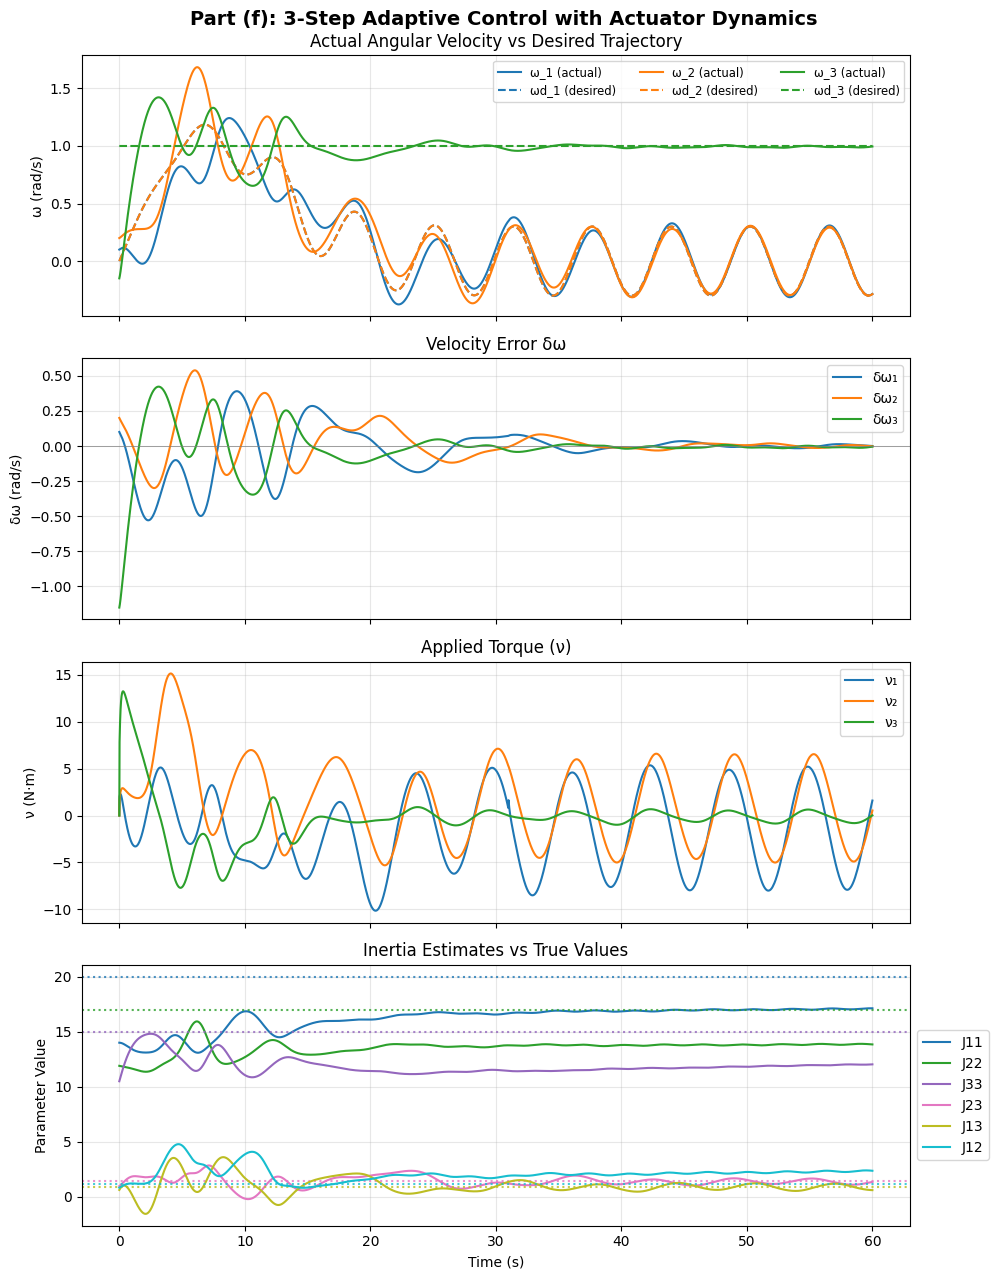

In [21]:
c1 = 1.0   
c2 = 5.0  
c3 = 10.0  
Gamma = 5.0 * np.eye(6) 

# --- Global Memory for the Finite Difference Derivative ---
memory = {
    't_prev': 0.0,
    'alpha_prev': np.zeros(3),
    'd_alpha_current': np.zeros(3)
}


def omega_d(t):
    e = np.exp(-0.01 * t**2)
    f = 0.3 * np.cos(t) * (1 - e) + (0.08 * np.pi + 0.006 * np.sin(t)) * t * e
    return np.array([f, f, 1.0])

def omega_d_dot(t):
    e  = np.exp(-0.01 * t**2)
    de = -0.02 * t * e
    dA = -0.3 * np.sin(t) * (1 - e) + 0.3 * np.cos(t) * (-de)
    h  = 0.08 * np.pi + 0.006 * np.sin(t)
    dh = 0.006 * np.cos(t)
    dB = dh * t * e + h * e + h * t * de
    df = dA + dB
    return np.array([df, df, 0.0])

def skew(v):
    return np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])

def quat_to_rot(q):
    q0, qv = q[0], q[1:]
    return (q0**2 - np.dot(qv, qv)) * np.eye(3) + 2.0 * np.outer(qv, qv) - 2.0 * q0 * skew(qv)

def hamilton_product(p, q):
    p0, pv = p[0], p[1:]
    q0, qv = q[0], q[1:]
    return np.array([p0*q0 - np.dot(pv, qv), *(p0*qv + q0*pv + np.cross(pv, qv))])

def quat_conj(q):
    return np.array([q[0], -q[1], -q[2], -q[3]])

def E_matrix(q):
    q0, qv = q[0], q[1:]
    return np.vstack((-qv.reshape(1, 3), q0 * np.eye(3) + skew(qv)))

def L_matrix(v):
    return np.array([
        [v[0],  0,  0,  0, v[2], v[1]],
        [ 0, v[1],  0, v[2],  0, v[0]],
        [ 0,  0, v[2], v[1], v[0],  0]
    ])

def compute_adaptive_actuator_control(t, q, omega, qd, theta_hat, nu):
    wd  = omega_d(t)
    wdd = omega_d_dot(t)
 
    s = hamilton_product(quat_conj(qd), q)
    s = s / np.linalg.norm(s)
    s0, sv = s[0], s[1:]
    Rs = quat_to_rot(s)
 
    Rswd = Rs @ wd
    delta_omega = omega - Rswd
    phi = -np.cross(delta_omega, Rswd) + Rs @ wdd
    
    # 1. Backstepping Error (Same as Part e)
    z1 = delta_omega - c1 * sv
    
    # 2. Kinematic derivative
    sv_dot = 0.5 * (s0 * np.eye(3) + skew(sv)) @ delta_omega
    
    # 3. Backstepping Regressor Matrix W1 (Same as Part e)
    W = -skew(omega) @ L_matrix(omega) - L_matrix(phi)
    W1 = -W + c1 * L_matrix(sv_dot)
    
    # 4. Virtual Target Torque (This was 'u' in Part e, now called 'alpha')
    alpha = sv - c2 * z1 + W1 @ theta_hat
    
    # --- The Dirty Derivative of Virtual Target Torque ---
    dt = t - memory['t_prev']
    
    if dt > 1e-6:
        d_alpha = (alpha - memory['alpha_prev']) / dt
        memory['t_prev'] = t
        memory['alpha_prev'] = alpha
        memory['d_alpha_current'] = d_alpha
    else:
        d_alpha = memory['d_alpha_current']
    
    # 5. Actuator Error (z2)
    z2 = nu - alpha
    
    # 6. Actual Control Law (u = rate of change of torque)
    u = -z1 - c3 * z2 + d_alpha
    
    # 7. Parameter Update Law (Same as Part e)
    d_theta_hat = -Gamma @ W1.T @ z1
 
    return u, d_theta_hat, s, delta_omega, z2


def f_ode(t, x):
    q         = x[0:4] / np.linalg.norm(x[0:4])
    omega     = x[4:7]
    qd        = x[7:11] / np.linalg.norm(x[7:11])
    theta_hat = x[11:17]
    nu        = x[17:20] 
 
    u, d_theta_hat, _, _, _ = compute_adaptive_actuator_control(t, q, omega, qd, theta_hat, nu)
 
    dq  = 0.5 * (E_matrix(q)  @ omega)
    dqd = 0.5 * (E_matrix(qd) @ omega_d(t))
    dom = J_inv @ (-np.cross(omega, J @ omega) + nu) # Driven by actual torque 'nu'
    dnu = u # 'u' is the rate of change of torque
 
    return np.concatenate([dq, dom, dqd, d_theta_hat, dnu])


qv0     = np.array([0.1826, 0.1826, 0.1826])
q0_s    = -np.sqrt(1.0 - np.dot(qv0, qv0)) 
q_init  = np.array([q0_s, *qv0])
om_init = np.array([0.1, 0.2, -0.15])
qd_init = np.array([1.0, 0.0, 0.0, 0.0])
nu_init = np.zeros(3)

x0 = np.concatenate([q_init, om_init, qd_init, theta_hat_init, nu_init])
t_eval = np.linspace(0, 60, 3000)

print("Simulating 3-Step Backstepping...")
# Using BDF here to ensure the dirty derivative doesn't cause the solver to hang!
sol = solve_ivp(f_ode, (0, 60), x0, method='BDF', t_eval=t_eval, rtol=1e-5, atol=1e-7)

t = sol.t
om_sol     = sol.y[4:7]
theta_sol  = sol.y[11:17]
nu_sol     = sol.y[17:20]

fig, axes = plt.subplots(4, 1, figsize=(10, 13), sharex=True)
fig.suptitle('Part (f): 3-Step Adaptive Control with Actuator Dynamics', fontsize=14, fontweight='bold')

# --- 1. Angular Velocity: Actual vs Desired ---
ax = axes[0]
colors = ['tab:blue', 'tab:orange', 'tab:green']
omega_d_t = np.array([omega_d(ti) for ti in t])   # Calculate desired trajectory over time

for i in range(3):
    ax.plot(t, om_sol[i], color=colors[i], label=f'ω_{i+1} (actual)')
    ax.plot(t, omega_d_t[:, i], '--', color=colors[i], lw=1.5, label=f'ωd_{i+1} (desired)')

ax.set(ylabel='ω (rad/s)', title='Actual Angular Velocity vs Desired Trajectory')
ax.legend(ncol=3, loc='upper right', fontsize='small')
ax.grid(True, alpha=0.3)

# --- 2. Velocity Error ---
for i, lbl in enumerate(['δω₁', 'δω₂', 'δω₃']): 
    axes[1].plot(t, om_sol[i] - omega_d_t[:, i], label=lbl)
axes[1].set(ylabel='δω (rad/s)', title='Velocity Error δω')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0, color='gray', lw=0.5)

# --- 3. Actual Torque (nu) ---
for i, lbl in enumerate(['ν₁', 'ν₂', 'ν₃']): 
    axes[2].plot(t, nu_sol[i], label=lbl)
axes[2].set(ylabel='ν (N·m)', title='Applied Torque (ν)')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

# --- 4. Parameter Estimates ---
colors_param = plt.cm.tab10(np.linspace(0, 1, 6))
param_labels = ['J11', 'J22', 'J33', 'J23', 'J13', 'J12']
for i in range(6): 
    axes[3].plot(t, theta_sol[i, :], color=colors_param[i], label=f'{param_labels[i]}')
    axes[3].axhline(theta_true[i], color=colors_param[i], linestyle=':', alpha=0.8)
axes[3].set(ylabel='Parameter Value', xlabel='Time (s)', title='Inertia Estimates vs True Values')
axes[3].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()